In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
import os
sys.path.append('../python')
import utils
import treecorr
import threepoint
%matplotlib inline

In [3]:
from astropy.io import fits

In [4]:
# Get the data vector used for fitting
hdul = fits.open('../data/dv/real_map3_desy3_unblind_scalecut3pcf_796simcov_2025Mar11.fits')
data_split = np.split(hdul[1].data, 20)
std_split  = np.split(np.diag(hdul[2].data)**0.5, 20)

In [5]:
# Get the data vector used for fitting
# wide and finer filter bin
hdul = fits.open('../data/dv/real_map3_desy3_unblind_scalecut3pcf_r2_100_50_796simcov_2025Mar16.fits')
data_split_wf = np.split(hdul[1].data, 20)

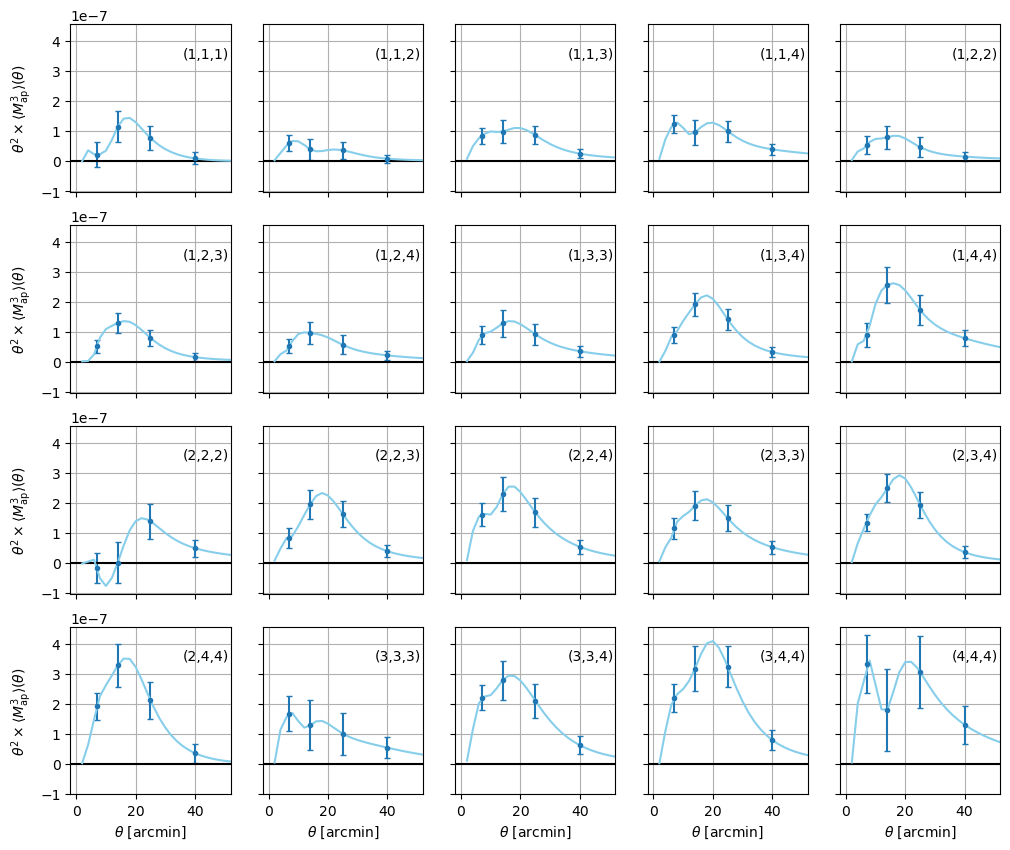

In [24]:
fig, axes = plt.subplots(4,5,figsize=(12, 10), sharex=True, sharey=True)
# for ax, data, std in zip(axes.flatten(), data_split, std_split):
for i in range(20):
    # Get for this
    ax = axes.flatten()[i]
    data = data_split[i]
    std = std_split[i]
    
    ax.errorbar(data['THETA1'], data['THETA1']**2*data['VALUE'], data['THETA1']**2*std, fmt='.', capsize=2)
    ax.grid()
    ax.axhline(0.0, color='k')

    data = data_split_wf[i]
    ax.plot(data['THETA1'], data['THETA1']**2*data['VALUE'], color='skyblue')
    # ax.plot(data['THETA1'], data['THETA1']**2*data['VALUE'], color='C0')

    # AUX
    ax.set_xlim(-2, 52)
    ax.text(0.7, 0.8, 
            '({},{},{})'.format(data['BIN1'][0]+1, data['BIN2'][0]+1, data['BIN3'][0]+1), 
            transform=ax.transAxes)
    
    if ax in axes[-1,:]:
        ax.set_xlabel(r'$\theta$ [arcmin]')
    if ax in axes[:, 0]:
        ax.set_ylabel(r'$\theta^2 \times\langle M_{\rm ap}^3\rangle(\theta)$')
    
plt.show()